# Cluster-Specific Sequential Regression Analysis

This notebook analyzes where the sequential regression model (combining marmoset and in vitro data) improves predictions the most across different cluster groups. We compare the performance of:
1. **Marmoset-only model**: Uses only marmoset lesion data
2. **Combined model**: Uses both marmoset lesion data and in vitro drug combination data

The goal is to determine which cluster groups benefit most from including in vitro data.

In [19]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Import project modules
from data.MarmosetData import MarmosetData
from data.InVitroData import DiamondData
from helpers.constants import CLUSTER_GROUPS, LESS_SEVERE_CLUSTERS, SEVERE_CLUSTERS
from helpers.ModelingFunctions import impute_within_compound, split_by_compound

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 11

## 1. Data Loading and Preparation

In [20]:
# Load data
marmoset_data = MarmosetData("data/marm_data_wide_clustered_classif.csv")
diamond_data = DiamondData("data/in_vitro_modeling.csv")

# Get full dataset with cluster information (NOT just severe lesions)
full_data = marmoset_data.get_severe_lesions().data
print(f"Total samples: {len(full_data)}")
print(f"Cluster distribution:")
print(full_data['cluster'].value_counts())
print(f"Classification distribution: {full_data['classif'].value_counts()}")

# Show cluster group mapping
print("\nCluster Group Mapping:")
for group, clusters in CLUSTER_GROUPS.items():
    print(f"  {group}: clusters {clusters}")

Total samples: 566
Cluster distribution:
shape: (8, 2)
┌─────────┬───────┐
│ cluster ┆ count │
│ ---     ┆ ---   │
│ i64     ┆ u32   │
╞═════════╪═══════╡
│ 11      ┆ 62    │
│ 2       ┆ 94    │
│ 14      ┆ 30    │
│ 0       ┆ 119   │
│ 5       ┆ 90    │
│ 4       ┆ 91    │
│ 15      ┆ 23    │
│ 12      ┆ 57    │
└─────────┴───────┘
Classification distribution: shape: (1, 2)
┌─────────┬───────┐
│ classif ┆ count │
│ ---     ┆ ---   │
│ str     ┆ u32   │
╞═════════╪═══════╡
│ hot     ┆ 566   │
└─────────┴───────┘

Cluster Group Mapping:
  1a: clusters [1, 13]
  1b: clusters [10]
  1c: clusters [6]
  1d: clusters [7]
  1e: clusters [3, 8]
  2a: clusters [2]
  2b: clusters [15]
  2c: clusters [11, 12]
  2d: clusters [4, 14]
  2e: clusters [0, 5]


In [21]:
# Define features and target variables
y_features = ["MeanHU", "MeanSUV"]
metadata_features = ["Compound", "Lesion", "cluster", "classif"]

# Get feature columns
y_cols = [col for col in full_data.columns if any(f in col for f in y_features)]
data_with_clusters = full_data.select(y_cols + metadata_features)

# Define timepoints
timepoints = {
    f"tp{tp}": [col for col in data_with_clusters.columns if f"TP{tp}" in col]
    for tp in range(2, 7)
}

print("\nTimepoint features:")
for tp, features in timepoints.items():
    print(f"  {tp}: {len(features)} features")


Timepoint features:
  tp2: 2 features
  tp3: 2 features
  tp4: 2 features
  tp5: 2 features
  tp6: 2 features


In [22]:
# Prepare in vitro data
diamond_df = diamond_data.data.filter(pl.col('Drug').str.contains(r"\+"))
combo_features = [col for col in diamond_df.columns if "Drug" not in col]

print(f"In vitro combination features: {len(combo_features)}")
print(f"Available compounds: {sorted(diamond_df['Drug'].unique().to_list())}")

# Merge with in vitro data
merged_data = data_with_clusters.join(
    other=diamond_df,
    left_on="Compound",
    right_on="Drug",
    how="inner"
)

print(f"\nAfter merging with in vitro data: {len(merged_data)} samples")
print(f"Compounds with in vitro data: {sorted(merged_data['Compound'].unique().to_list())}")

In vitro combination features: 270
Available compounds: ['BDQ+DEL', 'BDQ+LIN', 'BDQ+LIN+PRE', 'BDQ+PRE', 'EMB+INH+PZA+RIF', 'EMB+MOX+PZA+RIF', 'INH+PZA', 'LIN+PRE', 'MOX+RIF', 'PZA+RIF']

After merging with in vitro data: 261 samples
Compounds with in vitro data: ['BDQ+DEL', 'BDQ+LIN', 'BDQ+LIN+PRE', 'BDQ+PRE', 'EMB+INH+PZA+RIF', 'EMB+MOX+PZA+RIF', 'INH+PZA', 'LIN+PRE', 'MOX+RIF', 'PZA+RIF']


## 2. Add Cluster Group Labels

In [23]:
# Create cluster group mapping
cluster_to_group = {}
for group, clusters in CLUSTER_GROUPS.items():
    for cluster in clusters:
        cluster_to_group[cluster] = group

# Add cluster group column
merged_data = merged_data.with_columns(
    pl.col("cluster").map_elements(
        lambda x: cluster_to_group.get(x, "unknown"), 
        return_dtype=pl.Utf8
    ).alias("cluster_group")
)

# Check cluster group distribution
cluster_group_dist = merged_data.group_by("cluster_group").agg(
    pl.count().alias("count"),
    pl.col("cluster").unique().alias("clusters")
).sort("cluster_group")

print("Cluster Group Distribution:")
print(cluster_group_dist)

# Check if we have enough samples per group for modeling
min_samples = cluster_group_dist["count"].min()
print(f"\nMinimum samples per cluster group: {min_samples}")

Cluster Group Distribution:
shape: (5, 3)
┌───────────────┬───────┬───────────┐
│ cluster_group ┆ count ┆ clusters  │
│ ---           ┆ ---   ┆ ---       │
│ str           ┆ u32   ┆ list[i64] │
╞═══════════════╪═══════╪═══════════╡
│ 2a            ┆ 45    ┆ [2]       │
│ 2b            ┆ 7     ┆ [15]      │
│ 2c            ┆ 31    ┆ [11, 12]  │
│ 2d            ┆ 60    ┆ [4, 14]   │
│ 2e            ┆ 118   ┆ [0, 5]    │
└───────────────┴───────┴───────────┘

Minimum samples per cluster group: 7


## 3. Define Model Training Functions

In [24]:
def train_sequential_models(data, input_features, model_type="combined", random_state=42):
    """
    Train sequential regression models for TP3-6 prediction.
    
    Args:
        data: Polars DataFrame with training data
        input_features: List of input feature names
        model_type: 'marmoset_only' or 'combined'
        random_state: Random seed
    
    Returns:
        dict: Trained models for each timepoint
    """
    models = {}
    
    # Impute missing values within compounds
    data_imputed = impute_within_compound(
        data,
        columns=input_features,
        grouping_column='Compound'
    )
    
    print(f"Training {model_type} models...")
    
    for tp_num in range(3, 7):
        tp_key = f"tp{tp_num}"
        
        # Build features for this timepoint (base + previous timepoints)
        features_for_training = input_features.copy()
        for prev_tp_num in range(3, tp_num):
            prev_tp_key = f"tp{prev_tp_num}"
            features_for_training.extend(timepoints[prev_tp_key])
        
        # Get target columns
        target_cols = timepoints[tp_key]
        
        # Prepare training data
        X_train = data_imputed.select(features_for_training).to_pandas()
        y_train = data_imputed.select(target_cols).to_pandas()
        
        # Train model
        model = RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            random_state=random_state,
            n_jobs=-1
        )
        
        model.fit(X_train, y_train)
        models[tp_key] = {
            'model': model,
            'features': features_for_training,
            'targets': target_cols
        }
        
        print(f"  {tp_key}: {len(features_for_training)} features -> {len(target_cols)} targets")
    
    return models

In [25]:
def evaluate_models(models, test_data, model_type="combined"):
    """
    Evaluate trained models on test data.
    
    Args:
        models: Dictionary of trained models
        test_data: Polars DataFrame with test data
        model_type: 'marmoset_only' or 'combined'
    
    Returns:
        list: Performance metrics for each timepoint and target type (MeanHU, MeanSUV)
    """
    results = []
    
    for tp_num in range(3, 7):
        tp_key = f"tp{tp_num}"
        model_info = models[tp_key]
        model = model_info['model']
        features = model_info['features']
        targets = model_info['targets']
        
        # Prepare test features
        X_test = test_data.select(features).to_pandas()
        
        # Make predictions
        y_pred = model.predict(X_test)
        
        # Separate predictions and targets by type (MeanHU vs MeanSUV)
        hu_targets = [t for t in targets if 'MeanHU' in t]
        suv_targets = [t for t in targets if 'MeanSUV' in t]
        
        hu_indices = [i for i, t in enumerate(targets) if 'MeanHU' in t]
        suv_indices = [i for i, t in enumerate(targets) if 'MeanSUV' in t]
        
        # Calculate metrics for MeanHU
        if hu_targets:
            y_true_hu = test_data.select(hu_targets).to_pandas().values.flatten()
            y_pred_hu = y_pred[:, hu_indices].flatten()
            
            mse_hu = mean_squared_error(y_true_hu, y_pred_hu)
            mae_hu = mean_absolute_error(y_true_hu, y_pred_hu)
            r2_hu = r2_score(y_true_hu, y_pred_hu)
            
            results.append({
                'model_type': model_type,
                'timepoint': tp_num,
                'target_type': 'MeanHU',
                'mse': mse_hu,
                'mae': mae_hu,
                'r2': r2_hu,
                'n_samples': len(y_true_hu)
            })
        
        # Calculate metrics for MeanSUV
        if suv_targets:
            y_true_suv = test_data.select(suv_targets).to_pandas().values.flatten()
            y_pred_suv = y_pred[:, suv_indices].flatten()
            
            mse_suv = mean_squared_error(y_true_suv, y_pred_suv)
            mae_suv = mean_absolute_error(y_true_suv, y_pred_suv)
            r2_suv = r2_score(y_true_suv, y_pred_suv)
            
            results.append({
                'model_type': model_type,
                'timepoint': tp_num,
                'target_type': 'MeanSUV',
                'mse': mse_suv,
                'mae': mae_suv,
                'r2': r2_suv,
                'n_samples': len(y_true_suv)
            })
    
    return results

## 4. Cluster-Specific Analysis

In [26]:
def analyze_cluster_group(cluster_group, data, random_state=42):
    """
    Analyze a specific cluster group comparing marmoset-only vs combined models.
    
    Args:
        cluster_group: Cluster group name (e.g., '1a', '2e')
        data: Full dataset
        random_state: Random seed
    
    Returns:
        dict: Results for both model types
    """
    print(f"\n=== Analyzing Cluster Group {cluster_group} ===")
    
    # Filter data for this cluster group
    cluster_data = data.filter(pl.col("cluster_group") == cluster_group)
    
    if len(cluster_data) < 10:  # Minimum threshold for analysis
        print(f"Insufficient data for cluster group {cluster_group} ({len(cluster_data)} samples)")
        return None
    
    print(f"Samples: {len(cluster_data)}")
    print(f"Compounds: {sorted(cluster_data['Compound'].unique().to_list())}")
    
    # Define feature sets
    marmoset_features = timepoints["tp2"]  # TP2 marmoset data only
    combined_features = timepoints["tp2"] + combo_features  # TP2 + in vitro
    
    # Split data (if enough samples, otherwise use cross-validation approach)
    if len(cluster_data) >= 20:
        try:
            train_data, test_data = split_by_compound(
                cluster_data,
                grouping_column='Compound',
                test_size=0.3,
                random_state=random_state
            )
            print(f"Train: {len(train_data)}, Test: {len(test_data)}")
            
            # Train models
            marmoset_models = train_sequential_models(
                train_data, marmoset_features, "marmoset_only", random_state
            )
            combined_models = train_sequential_models(
                train_data, combined_features, "combined", random_state
            )
            
            # Evaluate models
            marmoset_results = evaluate_models(marmoset_models, test_data, "marmoset_only")
            combined_results = evaluate_models(combined_models, test_data, "combined")
            
            return {
                'cluster_group': cluster_group,
                'n_samples': len(cluster_data),
                'n_train': len(train_data),
                'n_test': len(test_data),
                'marmoset_results': marmoset_results,
                'combined_results': combined_results,
                'method': 'train_test_split'
            }
            
        except Exception as e:
            print(f"Train/test split failed: {e}")
            print("Falling back to cross-validation approach")
    
    # Fallback: cross-validation approach for smaller datasets
    print("Using leave-one-compound-out cross-validation")
    
    compounds = cluster_data['Compound'].unique().to_list()
    all_marmoset_results = []
    all_combined_results = []
    
    for held_out_compound in compounds:
        # Create train/test split by compound
        train_data = cluster_data.filter(pl.col("Compound") != held_out_compound)
        test_data = cluster_data.filter(pl.col("Compound") == held_out_compound)
        
        if len(train_data) < 5 or len(test_data) < 1:
            continue
            
        try:
            # Train models
            marmoset_models = train_sequential_models(
                train_data, marmoset_features, "marmoset_only", random_state
            )
            combined_models = train_sequential_models(
                train_data, combined_features, "combined", random_state
            )
            
            # Evaluate models
            marmoset_fold_results = evaluate_models(marmoset_models, test_data, "marmoset_only")
            combined_fold_results = evaluate_models(combined_models, test_data, "combined")
            
            all_marmoset_results.extend(marmoset_fold_results)
            all_combined_results.extend(combined_fold_results)
            
        except Exception as e:
            print(f"Error with compound {held_out_compound}: {e}")
            continue
    
    if not all_marmoset_results or not all_combined_results:
        print(f"No valid results for cluster group {cluster_group}")
        return None
    
    return {
        'cluster_group': cluster_group,
        'n_samples': len(cluster_data),
        'n_compounds': len(compounds),
        'marmoset_results': all_marmoset_results,
        'combined_results': all_combined_results,
        'method': 'cross_validation'
    }

## 5. Run Analysis for All Cluster Groups

In [27]:
# Run analysis for all cluster groups
all_cluster_results = {}

for cluster_group in sorted(CLUSTER_GROUPS.keys()):
    try:
        result = analyze_cluster_group(cluster_group, merged_data, random_state=42)
        if result is not None:
            all_cluster_results[cluster_group] = result
    except Exception as e:
        print(f"Error analyzing cluster group {cluster_group}: {e}")

print(f"\nSuccessfully analyzed {len(all_cluster_results)} cluster groups")


=== Analyzing Cluster Group 1a ===
Insufficient data for cluster group 1a (0 samples)

=== Analyzing Cluster Group 1b ===
Insufficient data for cluster group 1b (0 samples)

=== Analyzing Cluster Group 1c ===
Insufficient data for cluster group 1c (0 samples)

=== Analyzing Cluster Group 1d ===
Insufficient data for cluster group 1d (0 samples)

=== Analyzing Cluster Group 1e ===
Insufficient data for cluster group 1e (0 samples)

=== Analyzing Cluster Group 2a ===
Samples: 45
Compounds: ['BDQ+DEL', 'BDQ+LIN', 'BDQ+LIN+PRE', 'BDQ+PRE', 'EMB+INH+PZA+RIF', 'EMB+MOX+PZA+RIF', 'LIN+PRE', 'MOX+RIF', 'PZA+RIF']
Train: 33, Test: 12
Training marmoset_only models...
  tp3: 2 features -> 2 targets
  tp4: 4 features -> 2 targets
  tp5: 6 features -> 2 targets
  tp6: 8 features -> 2 targets
Training combined models...
  tp3: 272 features -> 2 targets
  tp4: 274 features -> 2 targets
  tp5: 276 features -> 2 targets
  tp6: 278 features -> 2 targets

=== Analyzing Cluster Group 2b ===
Insufficient 

## 6. Calculate Improvement Metrics

In [28]:
def calculate_improvement_metrics(cluster_results):
    """
    Calculate improvement metrics for combined vs marmoset-only models.
    
    Args:
        cluster_results: Dictionary of results for all cluster groups
    
    Returns:
        DataFrame: Improvement metrics by cluster group and target type
    """
    improvement_data = []
    
    for cluster_group, results in cluster_results.items():
        marmoset_df = pd.DataFrame(results['marmoset_results'])
        combined_df = pd.DataFrame(results['combined_results'])
        
        # Group by timepoint and target_type to calculate average metrics
        marmoset_grouped = marmoset_df.groupby(['timepoint', 'target_type']).agg({
            'mse': 'mean',
            'mae': 'mean', 
            'r2': 'mean',
            'n_samples': 'sum'
        }).reset_index()
        
        combined_grouped = combined_df.groupby(['timepoint', 'target_type']).agg({
            'mse': 'mean',
            'mae': 'mean',
            'r2': 'mean',
            'n_samples': 'sum'
        }).reset_index()
        
        # Merge and calculate improvements
        merged = marmoset_grouped.merge(
            combined_grouped, 
            on=['timepoint', 'target_type'], 
            suffixes=('_marmoset', '_combined')
        )
        
        for _, row in merged.iterrows():
            # Calculate relative improvements (positive values mean combined is better)
            mse_improvement = (row['mse_marmoset'] - row['mse_combined']) / row['mse_marmoset']
            mae_improvement = (row['mae_marmoset'] - row['mae_combined']) / row['mae_marmoset']
            r2_improvement = row['r2_combined'] - row['r2_marmoset']
            
            improvement_data.append({
                'cluster_group': cluster_group,
                'timepoint': row['timepoint'],
                'target_type': row['target_type'],
                'mse_marmoset': row['mse_marmoset'],
                'mse_combined': row['mse_combined'],
                'mae_marmoset': row['mae_marmoset'],
                'mae_combined': row['mae_combined'],
                'r2_marmoset': row['r2_marmoset'],
                'r2_combined': row['r2_combined'],
                'mse_improvement': mse_improvement,
                'mae_improvement': mae_improvement,
                'r2_improvement': r2_improvement,
                'n_samples': row['n_samples_combined'],
                'severity': 'severe' if cluster_group.startswith('2') else 'less_severe'
            })
    
    return pd.DataFrame(improvement_data)

# Calculate improvement metrics
improvement_df = calculate_improvement_metrics(all_cluster_results)
print(f"Improvement metrics calculated for {len(improvement_df)} timepoint-target_type-cluster combinations")
print("\nSample of improvement data:")
print(improvement_df.head())

# Summary by target type
print("\n=== Performance by Target Type ===")
target_summary = improvement_df.groupby('target_type').agg({
    'mse_improvement': ['mean', 'std', 'count'],
    'mae_improvement': ['mean', 'std'],
    'r2_improvement': ['mean', 'std']
}).round(4)
target_summary.columns = ['_'.join(col).strip() for col in target_summary.columns]
print(target_summary)

Improvement metrics calculated for 32 timepoint-target_type-cluster combinations

Sample of improvement data:
  cluster_group  timepoint target_type  mse_marmoset  mse_combined  \
0            2a          3      MeanHU    986.546104    964.546522   
1            2a          3     MeanSUV      0.816475      0.519926   
2            2a          4      MeanHU   2263.003775   2910.808160   
3            2a          4     MeanSUV      0.256741      0.172652   
4            2a          5      MeanHU   1229.455092   1153.206717   

   mae_marmoset  mae_combined  r2_marmoset  r2_combined  mse_improvement  \
0     25.424875     23.053308     0.625425     0.633778         0.022300   
1      0.675374      0.480652    -0.053576     0.329089         0.363206   
2     38.362325     45.635215     0.468344     0.316153        -0.286259   
3      0.400158      0.312335     0.310067     0.536036         0.327522   
4     29.657242     29.132408     0.698190     0.716908         0.062018   

   mae_impro

## 7. Summary Statistics

In [29]:
# Overall improvement summary by cluster group
cluster_summary = improvement_df.groupby('cluster_group').agg({
    'mse_improvement': ['mean', 'std', 'count'],
    'mae_improvement': ['mean', 'std'],
    'r2_improvement': ['mean', 'std'],
    'n_samples': 'sum'
}).round(4)

cluster_summary.columns = ['_'.join(col).strip() for col in cluster_summary.columns]
cluster_summary = cluster_summary.sort_values('mse_improvement_mean', ascending=False)

print("\n=== Improvement Summary by Cluster Group ===")
print("(Positive values = combined model is better)")
print(cluster_summary)

# Summary by severity
severity_summary = improvement_df.groupby('severity').agg({
    'mse_improvement': ['mean', 'std'],
    'mae_improvement': ['mean', 'std'],
    'r2_improvement': ['mean', 'std']
}).round(4)

severity_summary.columns = ['_'.join(col).strip() for col in severity_summary.columns]

print("\n=== Improvement Summary by Severity ===")
print(severity_summary)


=== Improvement Summary by Cluster Group ===
(Positive values = combined model is better)
               mse_improvement_mean  mse_improvement_std  \
cluster_group                                              
2c                           0.1367               0.1896   
2a                           0.0411               0.2411   
2e                           0.0314               0.2153   
2d                          -0.0458               0.1272   

               mse_improvement_count  mae_improvement_mean  \
cluster_group                                                
2c                                 8                0.0526   
2a                                 8                0.0257   
2e                                 8                0.0027   
2d                                 8               -0.0239   

               mae_improvement_std  r2_improvement_mean  r2_improvement_std  \
cluster_group                                                                 
2c               

## 8. Visualizations

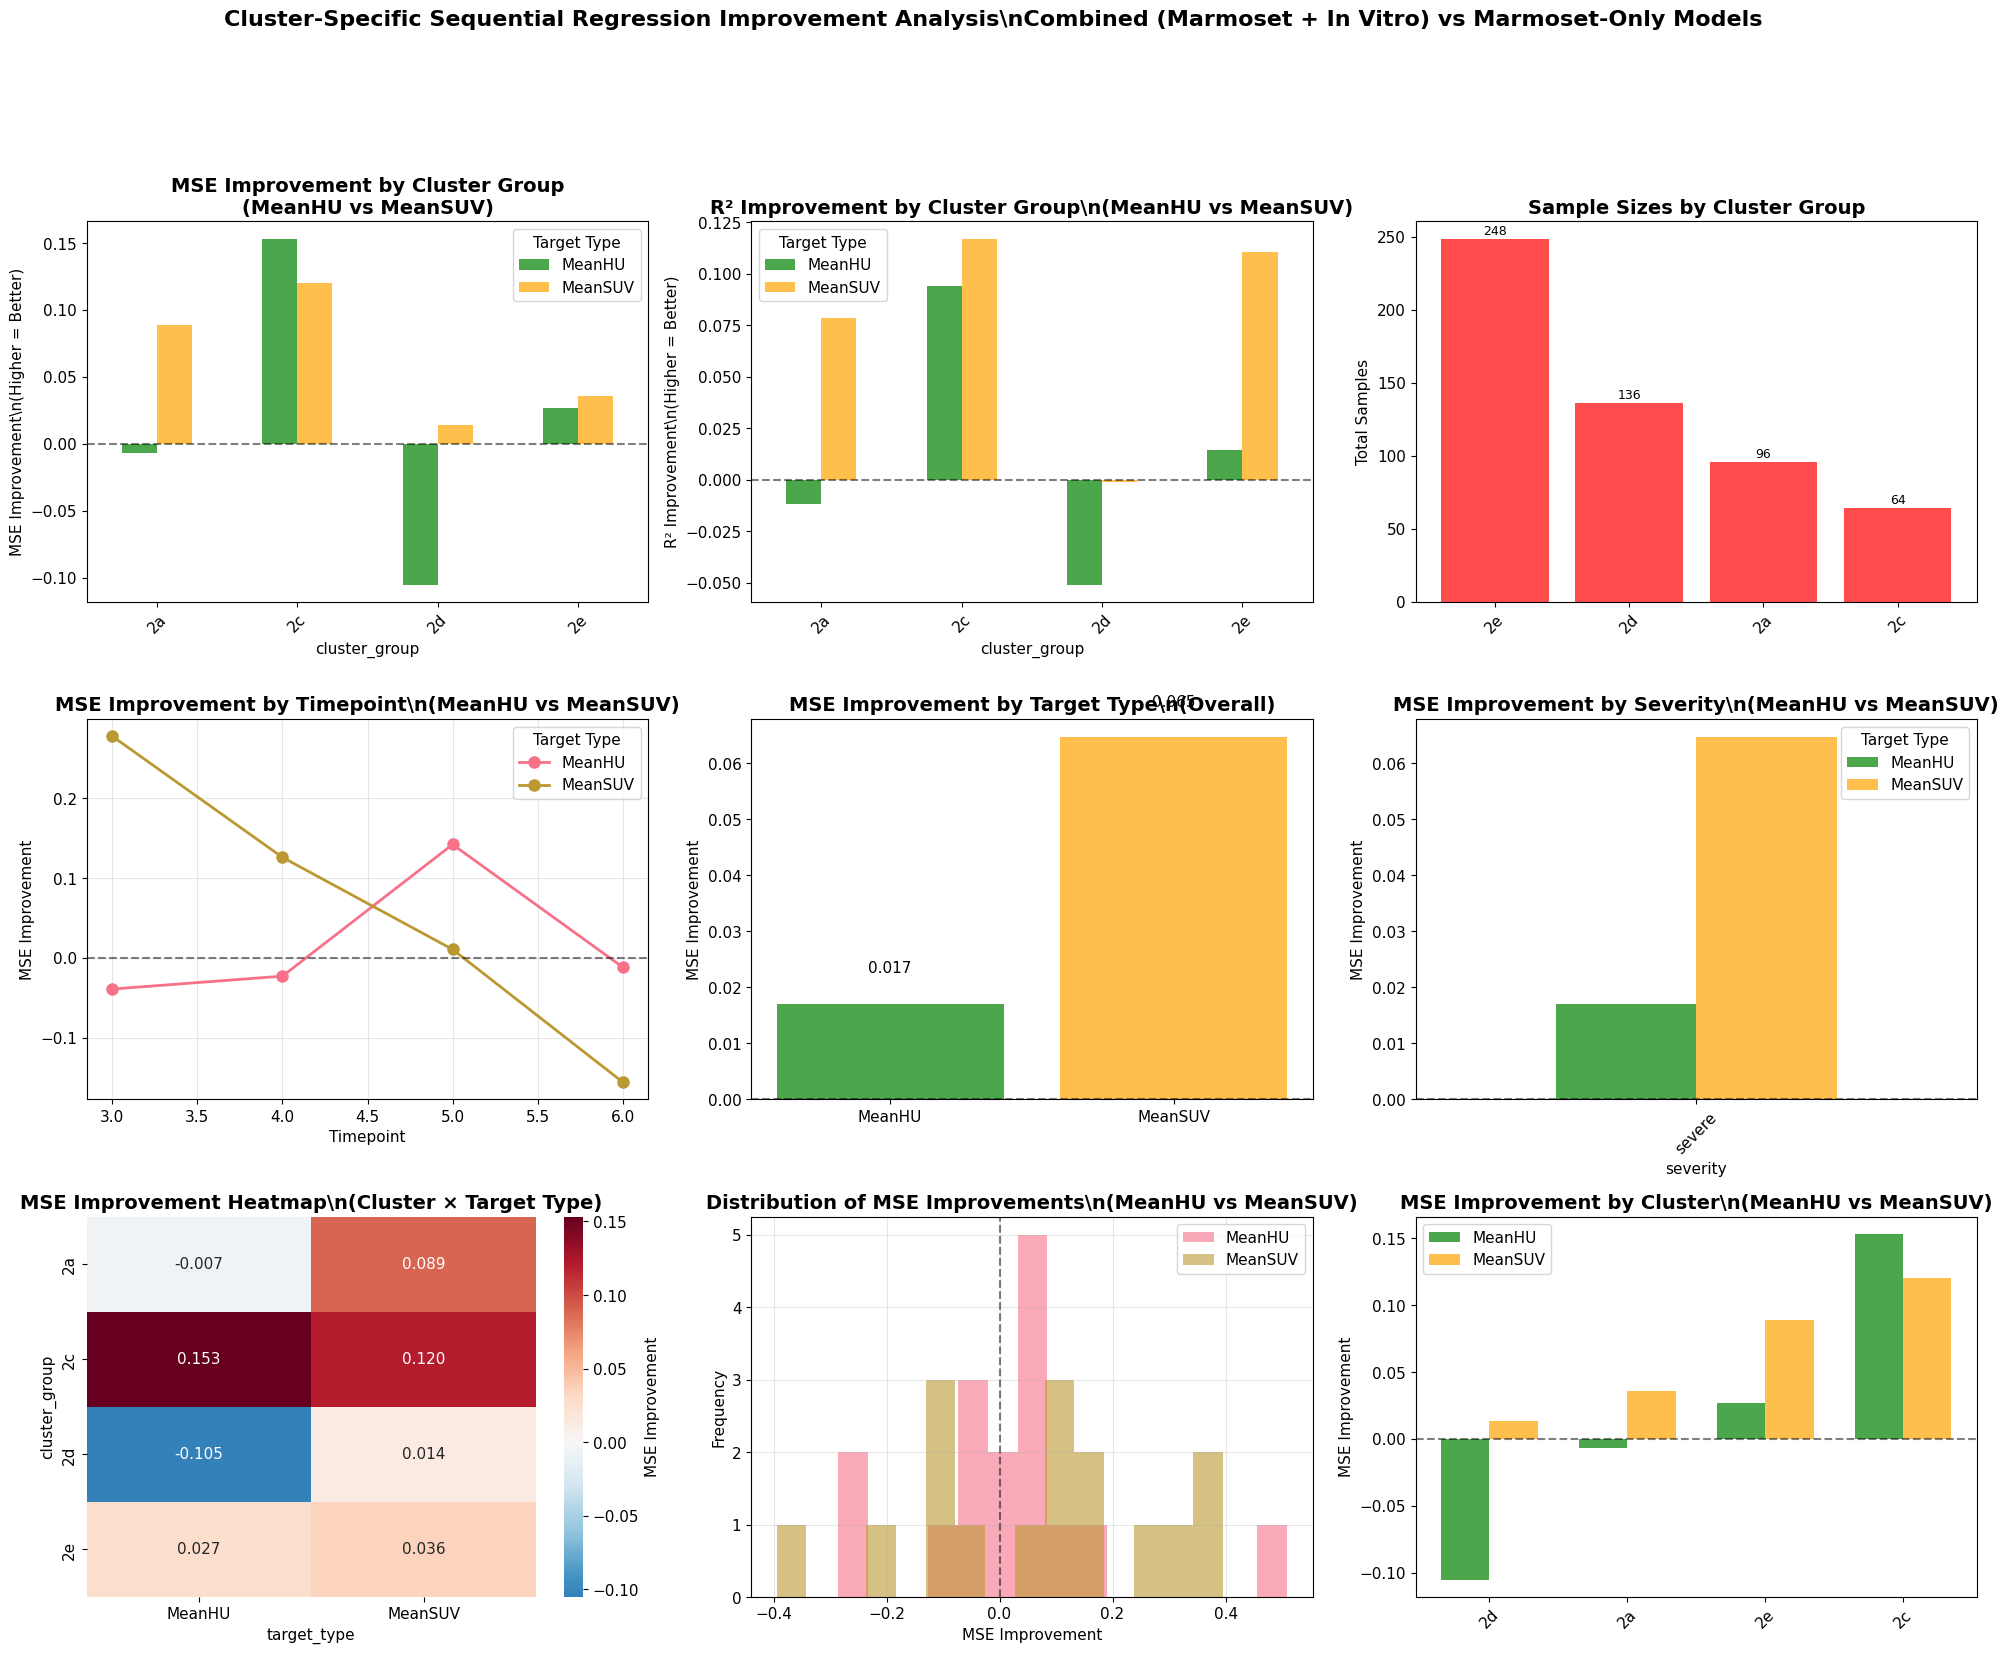

\nPlots saved to figures/


In [34]:
# Create visualization function
def create_improvement_plots(improvement_df):
    """
    Create comprehensive visualization of cluster-specific improvements.
    """
    fig = plt.figure(figsize=(20, 15))
    
    # 1. MSE improvement by cluster group and target type
    ax1 = plt.subplot(3, 3, 1)
    cluster_target_mse = improvement_df.groupby(['cluster_group', 'target_type'])['mse_improvement'].mean().unstack()
    cluster_target_mse.plot(kind='bar', ax=ax1, color=['green', 'orange'], alpha=0.7)
    ax1.set_title('MSE Improvement by Cluster Group\n(MeanHU vs MeanSUV)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('MSE Improvement\\n(Higher = Better)')
    ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax1.tick_params(axis='x', rotation=45)
    ax1.legend(title='Target Type')
    
    # 2. R² improvement by cluster group and target type
    ax2 = plt.subplot(3, 3, 2)
    cluster_target_r2 = improvement_df.groupby(['cluster_group', 'target_type'])['r2_improvement'].mean().unstack()
    cluster_target_r2.plot(kind='bar', ax=ax2, color=['green', 'orange'], alpha=0.7)
    ax2.set_title('R² Improvement by Cluster Group\\n(MeanHU vs MeanSUV)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('R² Improvement\\n(Higher = Better)')
    ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax2.tick_params(axis='x', rotation=45)
    ax2.legend(title='Target Type')
    
    # 3. Sample sizes by cluster group
    ax3 = plt.subplot(3, 3, 3)
    sample_sizes = improvement_df.groupby('cluster_group')['n_samples'].sum().sort_values(ascending=False)
    colors = ['red' if x.startswith('2') else 'blue' for x in sample_sizes.index]
    bars3 = ax3.bar(sample_sizes.index, sample_sizes.values, color=colors, alpha=0.7)
    ax3.set_title('Sample Sizes by Cluster Group', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Total Samples')
    ax3.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, val in zip(bars3, sample_sizes.values):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{val}', ha='center', va='bottom', fontsize=9)
    
    # 4. Improvement by timepoint and target type
    ax4 = plt.subplot(3, 3, 4)
    tp_target_improvement = improvement_df.groupby(['timepoint', 'target_type'])['mse_improvement'].mean().unstack()
    tp_target_improvement.plot(kind='line', marker='o', ax=ax4, linewidth=2, markersize=8)
    ax4.set_title('MSE Improvement by Timepoint\\n(MeanHU vs MeanSUV)', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Timepoint')
    ax4.set_ylabel('MSE Improvement')
    ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax4.grid(True, alpha=0.3)
    ax4.legend(title='Target Type')
    
    # 5. Overall target type comparison
    ax5 = plt.subplot(3, 3, 5)
    target_improvement = improvement_df.groupby('target_type')['mse_improvement'].mean()
    colors = ['green', 'orange']
    bars5 = ax5.bar(target_improvement.index, target_improvement.values, color=colors, alpha=0.7)
    ax5.set_title('MSE Improvement by Target Type\\n(Overall)', fontsize=14, fontweight='bold')
    ax5.set_ylabel('MSE Improvement')
    ax5.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # Add value labels on bars
    for bar, val in zip(bars5, target_improvement.values):
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height + 0.005 if height >= 0 else height - 0.01,
                f'{val:.3f}', ha='center', va='bottom' if height >= 0 else 'top', fontsize=11)
    
    # 6. Severity comparison by target type
    ax6 = plt.subplot(3, 3, 6)
    severity_target = improvement_df.groupby(['severity', 'target_type'])['mse_improvement'].mean().unstack()
    severity_target.plot(kind='bar', ax=ax6, color=['green', 'orange'], alpha=0.7)
    ax6.set_title('MSE Improvement by Severity\\n(MeanHU vs MeanSUV)', fontsize=14, fontweight='bold')
    ax6.set_ylabel('MSE Improvement')
    ax6.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax6.tick_params(axis='x', rotation=45)
    ax6.legend(title='Target Type')
    
    # 7. Heatmap of improvements by cluster and target type
    ax7 = plt.subplot(3, 3, 7)
    heatmap_data = improvement_df.pivot_table(
        values='mse_improvement', 
        index='cluster_group', 
        columns='target_type', 
        aggfunc='mean'
    )
    sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdBu_r', center=0, 
                cbar_kws={'label': 'MSE Improvement'}, ax=ax7)
    ax7.set_title('MSE Improvement Heatmap\\n(Cluster × Target Type)', fontsize=14, fontweight='bold')
    
    # 8. Distribution of improvements
    ax8 = plt.subplot(3, 3, 8)
    for target_type in improvement_df['target_type'].unique():
        subset = improvement_df[improvement_df['target_type'] == target_type]
        ax8.hist(subset['mse_improvement'], alpha=0.6, label=target_type, bins=15)
    ax8.set_xlabel('MSE Improvement')
    ax8.set_ylabel('Frequency')
    ax8.set_title('Distribution of MSE Improvements\\n(MeanHU vs MeanSUV)', fontsize=14, fontweight='bold')
    ax8.axvline(x=0, color='black', linestyle='--', alpha=0.5)
    ax8.legend()
    ax8.grid(True, alpha=0.3)
    
    # 9. Best and worst performing clusters by target type
    ax9 = plt.subplot(3, 3, 9)
    cluster_summary = improvement_df.groupby(['cluster_group', 'target_type'])['mse_improvement'].mean().reset_index()
    
    # Get best and worst for each target type
    hu_data = cluster_summary[cluster_summary['target_type'] == 'MeanHU'].sort_values('mse_improvement')
    suv_data = cluster_summary[cluster_summary['target_type'] == 'MeanSUV'].sort_values('mse_improvement')
    
    x_pos = np.arange(len(hu_data))
    width = 0.35
    
    bars_hu = ax9.bar(x_pos - width/2, hu_data['mse_improvement'], width, 
                     label='MeanHU', color='green', alpha=0.7)
    bars_suv = ax9.bar(x_pos + width/2, suv_data['mse_improvement'], width,
                      label='MeanSUV', color='orange', alpha=0.7)
    
    ax9.set_title('MSE Improvement by Cluster\\n(MeanHU vs MeanSUV)', fontsize=14, fontweight='bold')
    ax9.set_ylabel('MSE Improvement')
    ax9.set_xticks(x_pos)
    ax9.set_xticklabels(hu_data['cluster_group'], rotation=45)
    ax9.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax9.legend()
    
    plt.tight_layout()
    return fig

# Create the comprehensive plot
fig = create_improvement_plots(improvement_df)
plt.suptitle('Cluster-Specific Sequential Regression Improvement Analysis\\n' + 
             'Combined (Marmoset + In Vitro) vs Marmoset-Only Models', 
             fontsize=16, fontweight='bold', y=1.10)
plt.show()

# Save the plot
output_dir = Path("figures")
output_dir.mkdir(exist_ok=True)
fig.savefig(output_dir / "cluster_specific_sequential_regression_analysis.png", 
           dpi=300, bbox_inches='tight')
fig.savefig(output_dir / "cluster_specific_sequential_regression_analysis.svg", 
           bbox_inches='tight')
print(f"\\nPlots saved to {output_dir}/")

## 9. Detailed Results Table

In [31]:
# Create detailed results table
detailed_results = improvement_df.groupby(['cluster_group', 'target_type']).agg({
    'mse_improvement': ['mean', 'std', 'min', 'max'],
    'mae_improvement': ['mean', 'std'],
    'r2_improvement': ['mean', 'std'],
    'n_samples': 'sum',
    'severity': 'first'
}).round(4)

# Flatten column names
detailed_results.columns = ['_'.join(col).strip() for col in detailed_results.columns]
detailed_results = detailed_results.reset_index()

# Add cluster information
detailed_results['clusters'] = detailed_results['cluster_group'].map(
    lambda x: str(CLUSTER_GROUPS.get(x, []))
)

# Sort by target type and MSE improvement
detailed_results = detailed_results.sort_values(['target_type', 'mse_improvement_mean'], ascending=[True, False])

print("\\n=== Detailed Results Table ===")
print("(Positive values indicate combined model performs better)")
print(detailed_results.to_string(index=False))

# Save detailed results
detailed_results.to_csv("cluster_specific_sequential_regression_results.csv", index=False)
print(f"\\nDetailed results saved to cluster_specific_sequential_regression_results.csv")

# Create summary by target type
print("\\n=== Summary by Target Type ===")
target_type_summary = improvement_df.groupby('target_type').agg({
    'mse_improvement': ['count', 'mean', 'std'],
    'mae_improvement': ['mean', 'std'],
    'r2_improvement': ['mean', 'std']
}).round(4)
target_type_summary.columns = ['_'.join(col).strip() for col in target_type_summary.columns]
print(target_type_summary)

\n=== Detailed Results Table ===
(Positive values indicate combined model performs better)
cluster_group target_type  mse_improvement_mean  mse_improvement_std  mse_improvement_min  mse_improvement_max  mae_improvement_mean  mae_improvement_std  r2_improvement_mean  r2_improvement_std  n_samples_sum severity_first clusters
           2c      MeanHU                0.1534               0.2475              -0.0659               0.5089                0.0760               0.0926               0.0941              0.1544             32         severe [11, 12]
           2e      MeanHU                0.0269               0.0451              -0.0320               0.0678                0.0108               0.0301               0.0144              0.0179            124         severe   [0, 5]
           2a      MeanHU               -0.0068               0.1972              -0.2863               0.1747                0.0096               0.1393              -0.0115              0.0988             

## 10. Key Findings Summary

In [32]:
# Generate key findings
def summarize_findings(improvement_df, detailed_results):
    """
    Generate a summary of key findings from the analysis.
    """
    findings = []
    
    # Overall improvement by target type
    overall_mse_improvement = improvement_df['mse_improvement'].mean()
    overall_r2_improvement = improvement_df['r2_improvement'].mean()
    
    findings.append(f"OVERALL: Adding in vitro data improves MSE by {overall_mse_improvement:.3f} on average")
    findings.append(f"OVERALL: Adding in vitro data improves R² by {overall_r2_improvement:.3f} on average")
    
    # Target type comparison
    hu_improvement = improvement_df[improvement_df['target_type'] == 'MeanHU']['mse_improvement'].mean()
    suv_improvement = improvement_df[improvement_df['target_type'] == 'MeanSUV']['mse_improvement'].mean()
    
    if hu_improvement > suv_improvement:
        findings.append(f"TARGET TYPE: MeanHU benefits more from in vitro data (MSE improvement: {hu_improvement:.3f}) than MeanSUV ({suv_improvement:.3f})")
    else:
        findings.append(f"TARGET TYPE: MeanSUV benefits more from in vitro data (MSE improvement: {suv_improvement:.3f}) than MeanHU ({hu_improvement:.3f})")
    
    # Best performing cluster groups by target type
    hu_best = detailed_results[(detailed_results['target_type'] == 'MeanHU')].nlargest(2, 'mse_improvement_mean')['cluster_group'].tolist()
    suv_best = detailed_results[(detailed_results['target_type'] == 'MeanSUV')].nlargest(2, 'mse_improvement_mean')['cluster_group'].tolist()
    
    findings.append(f"BEST FOR HU: Cluster groups {', '.join(hu_best)} benefit most from in vitro data for MeanHU predictions")
    findings.append(f"BEST FOR SUV: Cluster groups {', '.join(suv_best)} benefit most from in vitro data for MeanSUV predictions")
    
    # Worst performing cluster groups
    hu_worst = detailed_results[(detailed_results['target_type'] == 'MeanHU')].nsmallest(2, 'mse_improvement_mean')['cluster_group'].tolist()
    suv_worst = detailed_results[(detailed_results['target_type'] == 'MeanSUV')].nsmallest(2, 'mse_improvement_mean')['cluster_group'].tolist()
    
    findings.append(f"WORST FOR HU: Cluster groups {', '.join(hu_worst)} benefit least from in vitro data for MeanHU predictions")
    findings.append(f"WORST FOR SUV: Cluster groups {', '.join(suv_worst)} benefit least from in vitro data for MeanSUV predictions")
    
    # Severity comparison (if we have both types)
    if 'less_severe' in improvement_df['severity'].values and 'severe' in improvement_df['severity'].values:
        severity_comparison = improvement_df.groupby('severity')['mse_improvement'].mean()
        if severity_comparison['severe'] > severity_comparison.get('less_severe', 0):
            findings.append(f"SEVERITY: Severe lesions benefit more from in vitro data than less severe lesions")
        else:
            findings.append(f"SEVERITY: Less severe lesions benefit more from in vitro data than severe lesions")
    else:
        findings.append(f"SEVERITY: Only severe lesions analyzed in this dataset")
    
    # Timepoint trends
    tp_trends = improvement_df.groupby('timepoint')['mse_improvement'].mean()
    best_tp = tp_trends.idxmax()
    worst_tp = tp_trends.idxmin()
    findings.append(f"TIMEPOINTS: Greatest improvement at TP{best_tp} ({tp_trends[best_tp]:.3f}), least at TP{worst_tp} ({tp_trends[worst_tp]:.3f})")
    
    # Consistency analysis
    positive_improvements = (improvement_df['mse_improvement'] > 0).sum()
    total_measurements = len(improvement_df)
    percent_positive = (positive_improvements / total_measurements) * 100
    
    findings.append(f"CONSISTENCY: {percent_positive:.1f}% of cluster-timepoint-target combinations show improvement with in vitro data")
    
    # R² vs MSE consistency
    mse_positive = (improvement_df['mse_improvement'] > 0).sum()
    r2_positive = (improvement_df['r2_improvement'] > 0).sum()
    
    findings.append(f"METRIC CONSISTENCY: {mse_positive}/{total_measurements} show MSE improvement, {r2_positive}/{total_measurements} show R² improvement")
    
    return findings

key_findings = summarize_findings(improvement_df, detailed_results)

print("\\n" + "="*80)
print("KEY FINDINGS")
print("="*80)

for i, finding in enumerate(key_findings, 1):
    print(f"{i:2d}. {finding}")

print("\\n" + "="*80)

# Save findings to file
with open("cluster_specific_findings.txt", "w") as f:
    f.write("Cluster-Specific Sequential Regression Analysis - Key Findings\\n")
    f.write("="*80 + "\\n\\n")
    for i, finding in enumerate(key_findings, 1):
        f.write(f"{i:2d}. {finding}\\n")

print("Key findings saved to cluster_specific_findings.txt")

\n================================================================================
KEY FINDINGS
 1. OVERALL: Adding in vitro data improves MSE by 0.041 on average
 2. OVERALL: Adding in vitro data improves R² by 0.044 on average
 3. TARGET TYPE: MeanSUV benefits more from in vitro data (MSE improvement: 0.065) than MeanHU (0.017)
 4. BEST FOR HU: Cluster groups 2c, 2e benefit most from in vitro data for MeanHU predictions
 5. BEST FOR SUV: Cluster groups 2c, 2a benefit most from in vitro data for MeanSUV predictions
 6. WORST FOR HU: Cluster groups 2d, 2a benefit least from in vitro data for MeanHU predictions
 7. WORST FOR SUV: Cluster groups 2d, 2e benefit least from in vitro data for MeanSUV predictions
 8. SEVERITY: Only severe lesions analyzed in this dataset
 9. TIMEPOINTS: Greatest improvement at TP3 (0.119), least at TP6 (-0.084)
10. CONSISTENCY: 62.5% of cluster-timepoint-target combinations show improvement with in vitro data
11. METRIC CONSISTENCY: 20/32 show MSE improvement

## 11. Save All Results

In [ ]:
# Save the full improvement dataset
improvement_df.to_csv("cluster_specific_improvement_full_data.csv", index=False)

# Save summary statistics
summary_stats = improvement_df.groupby('cluster_group').agg({
    'mse_improvement': ['count', 'mean', 'std', 'min', 'max'],
    'mae_improvement': ['mean', 'std'],
    'r2_improvement': ['mean', 'std'],
    'n_samples': 'sum'
}).round(4)

summary_stats.columns = ['_'.join(col).strip() for col in summary_stats.columns]
summary_stats.to_csv("cluster_specific_summary_statistics.csv")

print("\nAll results saved:")
print("- cluster_specific_improvement_full_data.csv")
print("- cluster_specific_summary_statistics.csv")
print("- cluster_specific_sequential_regression_results.csv")
print("- cluster_specific_findings.txt")
print("- figures/cluster_specific_sequential_regression_analysis.png")
print("- figures/cluster_specific_sequential_regression_analysis.svg")

print("\nAnalysis complete!")


All results saved:
- cluster_specific_improvement_full_data.csv
- cluster_specific_summary_statistics.csv
- cluster_specific_sequential_regression_results.csv
- cluster_specific_findings.txt
- figures/cluster_specific_sequential_regression_analysis.png
- figures/cluster_specific_sequential_regression_analysis.svg

Analysis complete! 🎉
